TOPOMAP

Extracting BDF parameters from ../data/sub-060_task-med2_eeg.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 617471  =      0.000 ...   602.999 secs...
Effective window size : 4.000 (s)


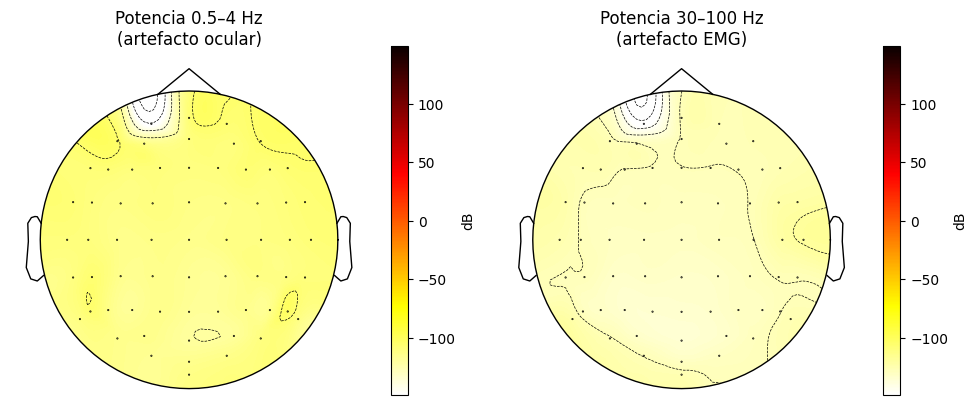

In [73]:
import mne
import numpy as np
import matplotlib.pyplot as plt


raw = mne.io.read_raw_bdf(input_fname='../data/sub-060_task-med2_eeg.bdf', preload=True)
eeg_channels = raw.ch_names[:64]
raw_eeg = raw.copy().pick(eeg_channels)

montage = mne.channels.make_standard_montage('biosemi64')
raw_eeg.set_montage(montage)

spectrum = raw_eeg.compute_psd(method='welch', fmin=0.5, fmax=48, n_fft=4096)
freqs = spectrum.freqs
psds = spectrum.get_data()

mask_ocular = (freqs >= 0.5) & (freqs <= 4)
power_ocular_db = 10 * np.log10(psds[:, mask_ocular].mean(axis=1))

mask_emg = (freqs >= 30) & (freqs <= 100) ####
power_emg_db = 10 * np.log10(psds[:, mask_emg].mean(axis=1))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im1, _ = mne.viz.plot_topomap(power_ocular_db, raw_eeg.info, axes=axes[0],
                               show=False, cmap='hot_r')
axes[0].set_title('Potencia 0.5–4 Hz\n(artefacto ocular)')
plt.colorbar(im1, ax=axes[0], label='dB')

im2, _ = mne.viz.plot_topomap(power_emg_db, raw_eeg.info, axes=axes[1],
                               show=False, cmap='hot_r')
axes[1].set_title('Potencia 30–100 Hz\n(artefacto EMG)')
plt.colorbar(im2, ax=axes[1], label='dB')

plt.tight_layout()
plt.show()

Extracting BDF parameters from ../data/sub-070_task-med2_eeg.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 616447  =      0.000 ...   601.999 secs...
Filtering raw data in 1 contiguous segment
Setting up low-pass filter at 1e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 100.00 Hz
- Upper transition bandwidth: 25.00 Hz (-6 dB cutoff frequency: 112.50 Hz)
- Filter length: 137 samples (0.134 s)

Effective window size : 4.000 (s)


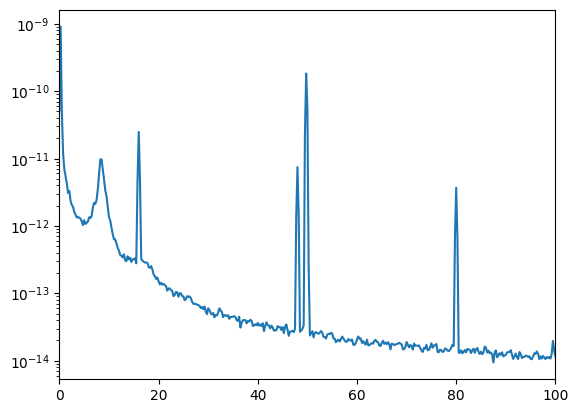

Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 6759 samples (6.601 s)

Effective window size : 4.000 (s)


/var/folders/84/36b4ykhj7dx3c82r40v03c580000gn/T/ipykernel_1362/2643467145.py:61: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0,100)


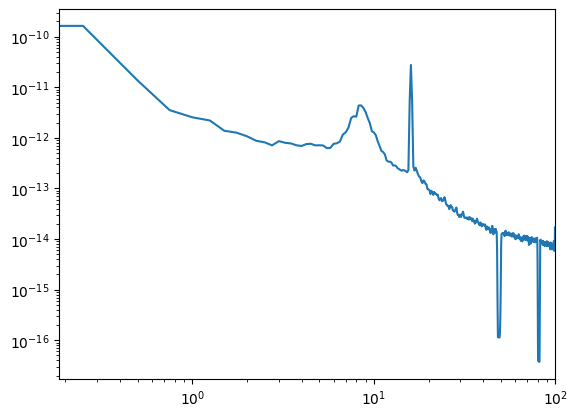

3.2805401803355122e-12
4.5480944714884244e-12
7.591585341040203e-12
1.1302558245163406e-11
[1.09407917e-11 1.63853045e-10 1.36331065e-11 3.53748321e-12
 2.55686865e-12 2.20625321e-12 1.38385391e-12 1.26962845e-12
 1.07740688e-12 8.76474192e-13 8.18936717e-13 7.12347134e-13
 8.64028527e-13 7.99056902e-13 7.76116188e-13 7.13260557e-13
 6.92727442e-13 7.55356627e-13 7.65378347e-13 7.11778692e-13
 7.14576409e-13 7.08906783e-13 6.29768887e-13 6.32571547e-13
 7.62618844e-13 7.82455431e-13 8.47014561e-13 1.16262158e-12
 1.28989592e-12 1.60349784e-12 2.48436735e-12 2.68299395e-12
 2.62442279e-12 4.36068518e-12 4.39615168e-12 3.93646693e-12
 3.25046722e-12 2.47347558e-12 1.96506173e-12 1.36019314e-12
 1.28069952e-12 1.13433562e-12 8.56416400e-13 6.95075553e-13
 5.53942883e-13 5.25136400e-13 4.73558722e-13 3.60277746e-13
 3.39844233e-13 3.38593244e-13 3.26527977e-13 2.84407191e-13
 2.85626054e-13 2.79488520e-13 2.53113882e-13 2.41700341e-13
 2.32119245e-13 2.24618766e-13 2.31726016e-13 2.2708641

In [72]:
import os
import gdown
from pathlib import Path
import mne
import matplotlib.pyplot as plt
import numpy as np
import scipy
from mne.viz import plot_filter, plot_ideal_filter
import glob, os
import re
import pandas as pd
import openpyxl
from scipy.stats import spearmanr

from specparam import SpectralModel

raw = mne.io.read_raw_bdf(input_fname='../data/sub-070_task-med2_eeg.bdf', preload=True)
eeg_channels = raw.ch_names[:64]
#Me quedo solo con los EEG
raw_eeg=raw.copy().pick(eeg_channels)

#aplicamos pasabajos con fc=100 Hz
eeg_filtrado=raw_eeg.filter(l_freq=None, h_freq=100)

psds, freqs = mne.time_frequency.psd_array_welch(
    eeg_filtrado.get_data()[30], 
    sfreq=1024, 
    n_fft=4096,
    fmax=100,
    n_per_seg=4096, 
    output="power")

a= np.arange(49, 512, 32) 
b= np.arange(49,512,50)
freqs_notch = (np.concatenate((a,[49.7]), axis=None))
plt.plot(freqs,psds)
plt.semilogy()
plt.xlim(0,100)
plt.show()

#Aplico filtro nothc para sacar ruido de linea >50Hz

filtrado = mne.filter.notch_filter(
    eeg_filtrado.get_data()[20],
    Fs=1024,
    freqs=a,
    notch_widths = 2,
    method = 'fir'
)

psds_f, freqs_f = mne.time_frequency.psd_array_welch(
    filtrado, 
    sfreq=1024, 
    n_fft=4096,
    fmax=100,
    n_per_seg=4096, 
    output="power")

plt.plot(freqs_f, psds_f)
plt.loglog()
plt.xlim(0,100)
plt.show()

#ANALISIS PSD POR
bandas = [[1,4],[4, 8], [8,13],[13,30]]

for i in range(len(bandas)):
    mask = (freqs_f >= bandas[i][0]) & (freqs_f <= bandas[i][1])
    band_power = np.trapezoid(psds_f[mask],freqs_f[mask])
    print(band_power)


print(psds_f)
print(freqs_f)



ANALISIS PSD

In [69]:



regiones = {
"frontal": ["Fz", "F1", "F2", "F3", "F4","F5","F6","F7","F8"],
"central": ["Cz", "C1", "C2", "C3", "C4","C5","C6"],
"parietal": ["Pz", "P1", "P2", "P3", "P4","P5","P6","P7","P8"],
"occipital": ["Oz", "O1", "O2"],
}



bandas = {
"delta": [1,4],
"theta": [4,8],
"alfa": [8,13],
"beta": [13,30],
}


resultados_PSD = []
resultados_aperiodico = []
resultado_asimetria = []
for archivo in glob.glob("../data/*.bdf"):
    numero_sujeto = int(re.search(r'sub-(\d+)', archivo).group(1))
    if numero_sujeto < 60: 
        grupo = "CTR"
    else:
        grupo = "EXP"

    psd_F3 = None
    psd_F4 = None

    print("sujeto ",numero_sujeto)
    raw = mne.io.read_raw_bdf(input_fname=archivo, preload=True)
    for region, electrodos in regiones.items():
        eeg_channels = electrodos #ME QUEDO SOLO CON LOS CANALES QUE QUIERO DE CADA REGION 
        raw_eeg=raw.copy().pick(eeg_channels) 
        #ACA APLICAR PREPROCESAMIENTO   
       #aplicamos pasabajos con fc=100 Hz
        eeg_filtrado_100=raw_eeg.filter(l_freq=None, h_freq=100)

        freqs_notch= np.arange(49, 100, 32) 

        #Aplico filtro nothc para sacar ruido de linea >50Hz
        for canal in eeg_channels:
            #region = eeg_channels[p]
            filtrado_notch = mne.filter.notch_filter(
                eeg_filtrado_100.get_data(picks=canal)[0],
                Fs=1024,
                freqs=freqs_notch,
                notch_widths = 2,
                method = 'fir'
            )

            psds_f, freqs_f = mne.time_frequency.psd_array_welch(
                filtrado_notch, 
                sfreq=1024, 
                n_fft=4096,
                fmax=100,
                n_per_seg=4096, 
                output="power")
            
            #me guardo los psds para calcular la asimetria despues
            if canal in ["F3"]:
                psd_F3 = psds_f

            if canal in ["F4"]:
                psd_F4 = psds_f

            for banda, rango in bandas.items():
                
                mask = (freqs_f >= rango[0]) & (freqs_f <= rango[1])
                potencia = np.trapezoid(psds_f[mask],freqs_f[mask])

                resultados_PSD.append({
                "sujeto": numero_sujeto,
                "grupo": grupo,
                "region": region,
                "banda": banda,
                "potencia": potencia,
                })
                #analisis aperiodico
                sm = SpectralModel(verbose=False)
                freq_mask = (freqs_f >= 0.5) & (freqs_f <= 50)
                freqs_crop = freqs_f[freq_mask]
                psds_crop  = psds_f[freq_mask]

                # Initialize model object and fit power spectrum
                fm = SpectralModel(min_peak_height=0.1)
                fm.fit(freqs_crop, psds_crop)

                resultados_aperiodico.append({
                "sujeto": numero_sujeto,
                "grupo": grupo,
                "region": region,
                "aperiodico": fm.results.params.aperiodic.params[1],
                })

    #ASIMETRIA AFLFA (F3,F4)
    mask = (freqs_f >= 8) & (freqs_f <= 13)
    potencia_F4 = np.trapezoid(psd_F4[mask],freqs_f[mask])
    potencia_F3 = np.trapezoid(psd_F3[mask],freqs_f[mask])
    asimetria = np.log(potencia_F4) - np.log(potencia_F3)
    resultado_asimetria.append({
                "sujeto": numero_sujeto,
                "grupo": grupo,
                "asimetria": asimetria,
                })


       

df = pd.DataFrame(resultados_PSD)
resumen = df.groupby(["sujeto", "grupo", "region", "banda"])["potencia"].mean().reset_index()
resumen.to_csv("resumen_psd.csv", index=False)

df = pd.read_csv('resumen_psd.csv')
df["log_potencia"] = np.log10(df["potencia"])



sujeto  31
Extracting BDF parameters from ../data/sub-031_task-med2_eeg.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 626687  =      0.000 ...   611.999 secs...
Filtering raw data in 1 contiguous segment
Setting up low-pass filter at 1e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 100.00 Hz
- Upper transition bandwidth: 25.00 Hz (-6 dB cutoff frequency: 112.50 Hz)
- Filter length: 137 samples (0.134 s)

Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter

In [70]:
import pandas as pd
import numpy as np
from openpyxl import Workbook

df = pd.read_csv('resumen_psd.csv')
df["log_potencia"] = np.log10(df["potencia"])


orden_regiones = ["frontal", "central", "parietal", "occipital"]
orden_bandas = ["delta", "theta", "alfa", "beta"]

wb = Workbook()
wb.remove(wb.active)

for banda in orden_bandas:
    sub = df[df["banda"] == banda]
    ctr_suj = sorted(sub[sub["grupo"] == "CTR"]["sujeto"].unique())
    exp_suj = sorted(sub[sub["grupo"] == "EXP"]["sujeto"].unique())

    ws = wb.create_sheet(banda)
    ws.cell(2, 1, "region")
    col = 2
    for g, sujs in [("CTR", ctr_suj), ("EXP", exp_suj)]:
        for s in sujs:
            ws.cell(1, col, g)            # fila 1: grupo
            ws.cell(2, col, f"{g}_{s}")   # fila 2: ID sujeto (referencia)
            col += 1

    for ri, r in enumerate(orden_regiones, start=3):
        ws.cell(ri, 1, r)
        col = 2
        for g, sujs in [("CTR", ctr_suj), ("EXP", exp_suj)]:
            for s in sujs:
                v = sub[(sub.sujeto == s) & (sub.region == r)]["log_potencia"]
                ws.cell(ri, col, round(float(v.values[0]), 4))
                col += 1

    wb.save("tablas_prism_mixto.xlsx")

print("Listo: tablas_prism_mixto.xlsx")


df = pd.read_csv('resumen_psd.csv')
df["log_potencia"] = np.log10(df["potencia"])
df = df[df["sujeto"] != 54]  # excluir outlier; sacar esta línea para conservarlo

orden_regiones = ["frontal", "central", "parietal", "occipital"]
orden_bandas = ["delta", "theta", "alfa", "beta"]

wb = Workbook()
wb.remove(wb.active)

for banda in orden_bandas:
    sub = df[df["banda"] == banda]
    ws = wb.create_sheet(banda)
    ws.cell(2, 1, "grupo")

    col = 2
    for reg in orden_regiones:          # cada región = un grupo (Group A-D)
        for k in range(1, 12):          # 11 subcolumnas (réplicas = sujetos)
            ws.cell(1, col, reg)
            ws.cell(2, col, f"Y{k}")
            col += 1

    for ri, g in enumerate(["CTR", "EXP"], start=3):   # 2 filas: CTR y EXP
        ws.cell(ri, 1, g)
        sujs = sorted(sub[sub.grupo == g]["sujeto"].unique())
        col = 2
        for reg in orden_regiones:
            for k in range(11):
                if k < len(sujs):
                    v = sub[(sub.sujeto == sujs[k]) & (sub.region == reg)]["log_potencia"]
                    ws.cell(ri, col, round(float(v.values[0]), 4))
                col += 1

wb.save("tablas_prism_grafico.xlsx")
print("Listo: tablas_prism_grafico.xlsx")

Listo: tablas_prism_mixto.xlsx
Listo: tablas_prism_grafico.xlsx


APERIODICO

In [71]:
from scipy.stats import spearmanr

from specparam import SpectralModel, SpectralGroupModel
from specparam.plts.spectra import plot_spectra
from specparam.plts.annotate import plot_annotated_model
from specparam.plts.aperiodic import plot_aperiodic_params
from specparam.sim.params import Stepper, param_iter
from specparam.sim import sim_power_spectrum, sim_group_power_spectra
from specparam.measures.params import compute_time_constant, compute_knee_frequency

resultados_aperiodico = []
for archivo in glob.glob("../data/*.bdf"):
    numero_sujeto = int(re.search(r'sub-(\d+)', archivo).group(1))
    if numero_sujeto < 60: 
        grupo = "CTR"
    else:
        grupo = "EXP"
    
    raw = mne.io.read_raw_bdf(input_fname=archivo, preload=True)
    eeg_channels = raw.ch_names[:64]
    #Me quedo solo con los EEG
    raw_eeg=raw.copy().pick(eeg_channels)

        #aplicamos pasabajos con fc=100 Hz
    eeg_filtrado=raw_eeg.filter(l_freq=None, h_freq=100)

    psds, freqs = mne.time_frequency.psd_array_welch(
        eeg_filtrado.get_data(), 
        sfreq=1024, 
        n_fft=4096,
        fmax=100,
        n_per_seg=4096, 
        output="power")


    #Aplico filtro nothc para sacar ruido de linea >50Hz

    filtrado = mne.filter.notch_filter(
        eeg_filtrado.get_data()[30],
        Fs=1024,
        freqs=a,
        notch_widths = 2,
        method = 'fir'
    )

    psds_f, freqs_f = mne.time_frequency.psd_array_welch(
        filtrado, 
        sfreq=1024, 
        n_fft=4096,
        fmax=100,
        n_per_seg=4096, 
        output="power")


    sm = SpectralModel(verbose=False)
    freq_mask = (freqs_f >= 0.5) & (freqs_f <= 50)
    freqs_crop = freqs_f[freq_mask]
    psds_crop  = psds_f[freq_mask]

    # Initialize model object and fit power spectrum
    fm = SpectralModel(min_peak_height=0.1)
    fm.fit(freqs_crop, psds_crop)
    # Check the aperiodic parameters
    fm.results.params.aperiodic.params
    resultados_aperiodico.append({
                "sujeto": numero_sujeto,
                "grupo": grupo,
                "region": region,
                "aperiodico": fm.results.params.aperiodic.params[1],
                })
    


Extracting BDF parameters from ../data/sub-031_task-med2_eeg.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 626687  =      0.000 ...   611.999 secs...
Filtering raw data in 1 contiguous segment
Setting up low-pass filter at 1e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 100.00 Hz
- Upper transition bandwidth: 25.00 Hz (-6 dB cutoff frequency: 112.50 Hz)
- Filter length: 137 samples (0.134 s)

Effective window size : 4.000 (s)
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition band

KeyboardInterrupt: 

PASTO APERIODICO A CSV

In [48]:
df = pd.DataFrame(resultados_aperiodico)
resultados_aperiodico_por_region = df.groupby(["sujeto", "grupo", "region"])["aperiodico"].mean().reset_index()
resultados_aperiodico_por_region.to_csv("resultados_aperiodicos_por_region.csv", index=False)

In [53]:
df = pd.DataFrame(resultado_asimetria)
#resultados_aperiodico_por_region = df.groupby(["sujeto", "grupo", "region"])["aperiodico"].mean().reset_index()
df.to_csv("resultado_asimetria.csv", index=False)

ANALISIS EOG EMG

Extracting BDF parameters from ../data/sub-031_task-med2_eeg.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 626687  =      0.000 ...   611.999 secs...
Filtering raw data in 1 contiguous segment
Setting up low-pass filter at 1e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 100.00 Hz
- Upper transition bandwidth: 25.00 Hz (-6 dB cutoff frequency: 112.50 Hz)
- Filter length: 137 samples (0.134 s)

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 0.5 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transi

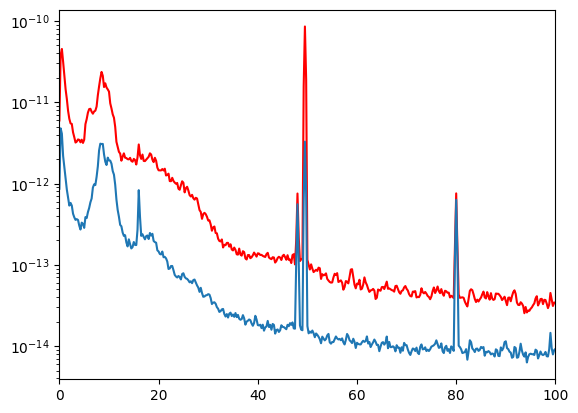

In [57]:
import os
import gdown
from pathlib import Path
import mne
import matplotlib.pyplot as plt
import numpy as np
import scipy
from mne.viz import plot_filter, plot_ideal_filter
import glob, os
import re
import pandas as pd
import openpyxl
from scipy.stats import spearmanr

from specparam import SpectralModel




raw = mne.io.read_raw_bdf(input_fname='../data/sub-031_task-med2_eeg.bdf', preload=True)
#eeg_channels = raw.ch_names[:64]
#Me quedo solo con los EEG
electrodos = ["F2", "P2"]
potencia=[0,0]
for i in range(len(electrodos)):
    raw_eeg=raw.copy().pick(electrodos[i]) 

    #aplicamos pasabajos con fc=100 Hz
    eeg_filtrado=raw_eeg.filter(l_freq=None, h_freq=100)
    eeg_filtrado_2=raw_eeg.filter(l_freq=0.5, h_freq=None)

    psds, freqs = mne.time_frequency.psd_array_welch(
        eeg_filtrado_2.get_data(), 
        sfreq=1024, 
        n_fft=4096,
        fmax=100,
        n_per_seg=4096, 
        output="power")
    
    potencia[i]=psds[0]
    print("ELECTRODO", electrodos[i])
    #print(freqs)
    #print(psds[1])
    
plt.plot(freqs, potencia[0],color = 'red')
plt.plot(freqs, potencia[1])
plt.semilogy()
plt.xlim(0,100)
plt.show()

    

  

    

